Notebook realizado por Juan David Sánchez. Contacto: juansanchez@unam.edu

Versión de Python: 3.14.3 (VS Code)

Nota: El código se realizará en inglés (a exepción de algunas anotaciones y prints) con el fin de reutilizarlo en un futuro.

# **Predicción de clases para el dataset BACE-1 usando KNN**

**About the dataset:** 

The BACE dataset provides quantitative (IC50) and qualitative (binary label) binding results for a set of inhibitors of human β-secretase 1 (BACE-1). All data are experimental values reported in scientific literature over the past decade, some with detailed crystal structures available. A collection of 1522 compounds with their 2D structures and properties are provided.

The data file contains a csv table, in which columns below are used:
     "mol" - SMILES representation of the molecular structure
     "pIC50" - Negative log of the IC50 binding affinity
     "class" - Binary labels for inhibitor

References:
Subramanian, Govindan, et al. "Computational modeling of β-secretase 1 (BACE-1) inhibitors using ligand based approaches." Journal of chemical information and modeling 56.10 (2016): 1936-1949.

**Resumen**

En este trabajo se desarrolló un flujo de trabajo de machine learning (KNN) para la clasificación de la actividad biológica de moléculas frente al blanco terapéutico BACE-1 (b-secretasa 1), una enzima clave asociada con la patogénesis de la enfermedad de Alzheimer.

Se realizó un pre-procesamiento de los datos, luego su respectiva división en datos de entrenamiento y de prueba (70-30 %), posteriormente se realizó una reducción de dimensioness por PCA para reducir su dispersión y por ende el sobreajuste para finalmente entrenar el modelo de KNN con n = 5.

**Abstract**

In this study, a machine learning workflow (KNN) was developed to classify the biological activity of molecules against the therapeutic target BACE-1 (b-secretase 1), a key enzyme associated with the pathogenesis of Alzheimer’s disease.

The data were preprocessed, then split into training and test sets (70–30%). Dimension reduction was subsequently performed using PCA to reduce data dispersion and thereby minimize overfitting, and finally, the KNN model was trained with n = 5.

In [89]:
# Importing necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
# Loading the dataset

df = pd.read_csv('bace.csv')
df.head()

,mol,CID,Class,Model,pIC50,MW,AlogP,HBA,HBD,RB,...,PEOE6 (PEOE6),PEOE7 (PEOE7),PEOE8 (PEOE8),PEOE9 (PEOE9),PEOE10 (PEOE10),PEOE11 (PEOE11),PEOE12 (PEOE12),PEOE13 (PEOE13),PEOE14 (PEOE14),canvasUID
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,BACE_1,1,Train,9.154901,431.56979,4.4014,3,2,5,...,53.205711,78.640335,226.85541,107.43491,37.133846,0.000000,7.980170,0.0,0.000000,1
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,BACE_2,1,Train,8.853872,657.81073,2.6412,5,4,16,...,73.817162,47.171600,365.67694,174.07675,34.923889,7.980170,24.148668,0.0,24.663788,2
2,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,BACE_3,1,Train,8.698970,591.74091,2.5499,4,3,11,...,70.365707,47.941147,192.40652,255.75255,23.654478,0.230159,15.879790,0.0,24.663788,3
3,S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...,BACE_4,1,Train,8.698970,591.67828,3.1680,4,3,12,...,56.657166,37.954151,194.35304,202.76335,36.498634,0.980913,8.188327,0.0,26.385181,4
4,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,BACE_5,1,Train,8.698970,629.71283,3.5086,3,3,11,...,78.945702,39.361153,179.71288,220.46130,23.654478,0.230159,15.879790,0.0,26.100143,5


In [91]:
# Previous analysis and data exploration

categorical_columns = df.select_dtypes(include=['object', 'str']).columns
print(f'🔶 Columnas categóricas: {list(categorical_columns)}')
print(f'🔷 El dataset contiene {df.shape[0]} filas y {df.shape[1]} columnas')

🔶 Columnas categóricas: ['mol', 'CID', 'Model']
🔷 El dataset contiene 1513 filas y 595 columnas


In [92]:
# Split the dataset into features and target variable
x = df.drop(columns=['mol', 'CID', 'Model', 'Class'])  # Features
y = df['Class']  # Target variable

x.head()

,pIC50,MW,AlogP,HBA,HBD,RB,HeavyAtomCount,ChiralCenterCount,ChiralCenterCountAllPossible,RingCount,...,PEOE6 (PEOE6),PEOE7 (PEOE7),PEOE8 (PEOE8),PEOE9 (PEOE9),PEOE10 (PEOE10),PEOE11 (PEOE11),PEOE12 (PEOE12),PEOE13 (PEOE13),PEOE14 (PEOE14),canvasUID
0,9.154901,431.56979,4.4014,3,2,5,32,2,2,4,...,53.205711,78.640335,226.85541,107.43491,37.133846,0.000000,7.980170,0.0,0.000000,1
1,8.853872,657.81073,2.6412,5,4,16,47,6,6,4,...,73.817162,47.171600,365.67694,174.07675,34.923889,7.980170,24.148668,0.0,24.663788,2
2,8.698970,591.74091,2.5499,4,3,11,42,2,3,5,...,70.365707,47.941147,192.40652,255.75255,23.654478,0.230159,15.879790,0.0,24.663788,3
3,8.698970,591.67828,3.1680,4,3,12,40,4,5,3,...,56.657166,37.954151,194.35304,202.76335,36.498634,0.980913,8.188327,0.0,26.385181,4
4,8.698970,629.71283,3.5086,3,3,11,44,2,3,5,...,78.945702,39.361153,179.71288,220.46130,23.654478,0.230159,15.879790,0.0,26.100143,5


In [93]:
# Splitting the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y) # stratify=y to maintain the same proportion of classes in both training and testing sets

In [94]:
# Scaling the training data using StandardScaler
from sklearn.preprocessing import StandardScaler
# z-score media = 0 std = 1 - z = x-mean/std

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [95]:
# Scaling the testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

In [96]:
# Reducing the dimensionality of the data using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components = 0.9, random_state=42) # Retain 90% of the variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f'🔷 Dimensiones reducidas de {X_train_scaled.shape[1]} a {X_train_pca.shape[1]} componentes principales')

🔷 Dimensiones reducidas de 591 a 40 componentes principales


In [97]:
# Training the KNN model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [98]:
# Lets evaluate the model's performance on the test set

y_pred = knn.predict(X_test_pca)

🔶 Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       247
           1       0.76      0.76      0.76       207

    accuracy                           0.78       454
   macro avg       0.78      0.78      0.78       454
weighted avg       0.78      0.78      0.78       454




🔷 Matriz de confusión:


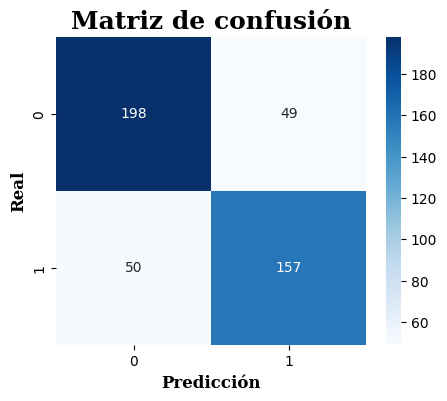

In [99]:
# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

# Classification report
print("🔶 Reporte de clasificación:")
print(classification_report(y_test, y_pred))

matrizknn = confusion_matrix(y_test, y_pred)

# Vizualizing the confusion matrix with a seaborn heatmap
plt.figure(figsize=(5,4))
sns.heatmap(matrizknn, annot=True, fmt='d', cmap='Blues')

plt.title('Matriz de confusión', fontsize = 18, fontweight='bold', fontfamily='serif')
plt.xlabel('Predicción', fontsize = 12, fontweight='bold', fontfamily='serif')
plt.ylabel('Real', fontsize = 12, fontweight='bold', fontfamily='serif')

print("\n🔷 Matriz de confusión:")
plt.show()